In [1]:
import numpy as np
import torch
import torch.nn as nn

import sys
sys.path.insert(0, '../include')

from plot import plot_wavefunction, plot_wavefunctions
from sampling import TrainConfig
from scipy_eigensolver import solve_1channel
from training import train_Rayleigh, train_Rayleigh_PDE
from validation import validate, print_metrics

Define parameters

In [3]:
V0 = 70.92
R0 = 1.5

r_min = 1e-4
r_max = 30.0
r = np.linspace(r_min, r_max, 1000)

Solve with scipy

Ground state energy E = -2.225570 MeV


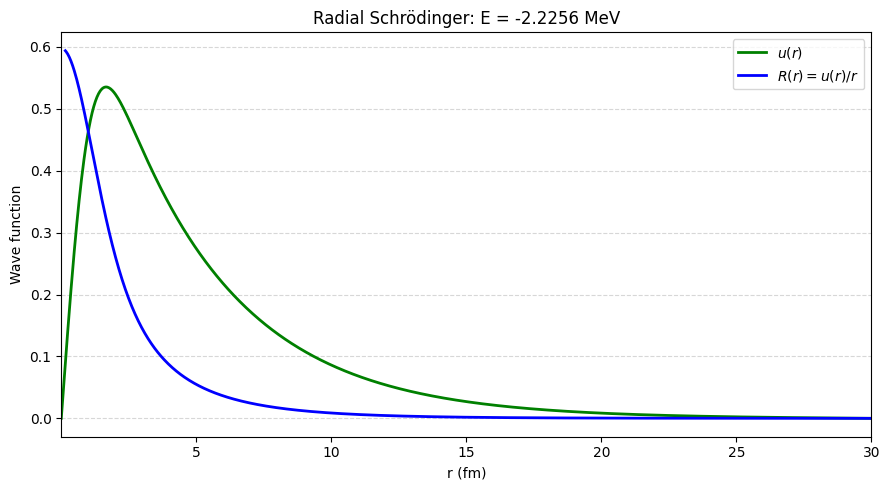

In [4]:
def V(r):
    return -V0 * np.exp(-r**2 / R0**2)

E_scipy, u_scipy, R_scipy = solve_1channel(V, r)
plot_wavefunction(r, u_scipy, R_scipy, E_scipy)

Define a neural network $N_\theta(r)$ that approximates the radial wave function via an ansatz
$$
u_\theta(r) = r e^{-\alpha r} N_{\theta}(r) \text{ with } \alpha = 0.25 \text{ fm}^{-1}.
$$
The network input is rescaled from $[0,r_{\max}]$ to $[-1,1]$.

In [5]:
class RadialNet(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=3, alpha=0.25, energy_init=-3.0):
        # Define layers
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

        self.register_buffer('alpha', torch.tensor(float(alpha)))
        self.energy = nn.Parameter(torch.tensor([energy_init], dtype=torch.float32))

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.dtype = torch.float32

        self.r_min = r_min
        self.r_max = r_max
        self.R = None

    # Forward pass
    def forward(self, r):
        # r is expected to be of shape (N, 1)
        x = 2.0 * r / self.r_max - 1.0 # mapping to [-1,1]
        return r * torch.exp(-self.alpha * r) * self.net(x)

    # Potential
    def potential(self, r):
        return -V0 * torch.exp(-r**2 / R0**2)

Train with Rayleigh energy only

In [9]:
cfg = TrainConfig()
cfg.n_rayleigh = 5000

model = RadialNet()

history = train_Rayleigh(model, cfg, stop=1e-3)

{'step': 1, 'loss': 5.607603073120117, 'rayleigh': -0.9834387302398682, 'norm_loss': 0.6591039299964905, 'boundary_loss': 2.792641566884413e-07, 'E': -0.9834387302398682}
{'step': 500, 'loss': -3.091747760772705, 'rayleigh': -3.1963653564453125, 'norm_loss': 0.010460898280143738, 'boundary_loss': 8.469445447190083e-07, 'E': -3.1963653564453125}
{'step': 1000, 'loss': -1.891028642654419, 'rayleigh': -1.9009416103363037, 'norm_loss': 0.0009908074280247092, 'boundary_loss': 4.925449843540264e-07, 'E': -1.9009416103363037}
{'step': 1500, 'loss': -1.971770167350769, 'rayleigh': -1.9901697635650635, 'norm_loss': 0.0018387914169579744, 'boundary_loss': 1.1650065516732866e-06, 'E': -1.9901697635650635}
{'step': 2000, 'loss': -2.7686402797698975, 'rayleigh': -2.778677463531494, 'norm_loss': 0.001003402634523809, 'boundary_loss': 3.087933464485104e-07, 'E': -2.778677463531494}
{'step': 2500, 'loss': -1.3022971153259277, 'rayleigh': -1.338489055633545, 'norm_loss': 0.0036188431549817324, 'boundar

In [10]:
metrics, u_nn, R_nn = validate(r, u_scipy, R_scipy, E_scipy, model)
print_metrics(metrics)

  rayleigh_energy: -2.2141628
  norm_loss: 0.0015126828
  pde_loss: 0.12055289
  u_rmax: -0.00082675653
  l2: 0.017283303
  learned_energy: -2.1972687
  energy_error: 0.028301091


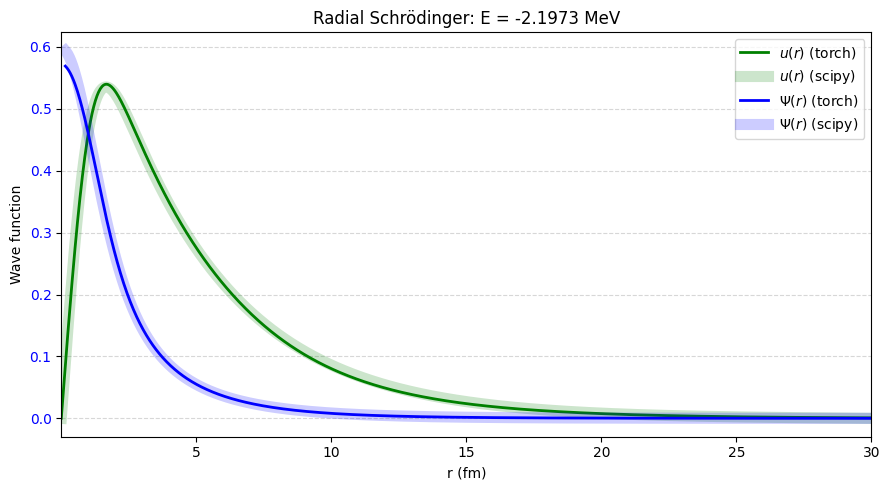

In [11]:
plot_wavefunctions(r, u_scipy, R_scipy, u_nn, R_nn, metrics['learned_energy'])

Train with both Rayleigh and PDE terms

In [18]:
cfg2 = TrainConfig()
cfg2.n_origin = 2000
#cfg2.n_pde = 8000
#cfg2.n_rayleigh = 8000
#cfg2.grad_balance_pde_scale = 3.0
#cfg2.grad_balance_match_scale = 2.0

model2 = RadialNet()

history2 = train_Rayleigh_PDE(model2, cfg2, stop=1e-3)

{'step': 1, 'loss': 8.561530113220215, 'rayleigh': -0.6996101140975952, 'pde_loss': 0.14809802174568176, 'match_loss': 5.291792869567871, 'norm_loss': 0.9261125922203064, 'boundary_loss': 1.466308162889618e-06, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 500, 'loss': -1.9460200071334839, 'rayleigh': -1.9939721822738647, 'pde_loss': 66.80077362060547, 'match_loss': 1.0120919942855835, 'norm_loss': 0.004794652573764324, 'boundary_loss': 5.605501769423427e-07, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1000, 'loss': -1.1198927164077759, 'rayleigh': -1.1210671663284302, 'pde_loss': 25.83957862854004, 'match_loss': 3.530388593673706, 'norm_loss': 0.00011558547703316435, 'boundary_loss': 1.8643385146788205e-06, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1500, 'loss': -2.305814027786255, 'rayleigh': -2.306581497192383, 'pde_loss': 10.611969947814941, 'match_loss': 0.4808292090892792, 'norm_loss': 7.630961772520095e-05, 'boundary_loss': 4.19851

In [19]:
metrics2, u_nn2, R_nn2 = validate(r, u_scipy, R_scipy, E_scipy, model2)
print_metrics(metrics2)

  rayleigh_energy: -2.2206998
  norm_loss: 0.0014253509
  pde_loss: 0.01061443
  u_rmax: 0.0015350789
  l2: 0.026573708
  learned_energy: -2.2233429
  energy_error: 0.0022269199


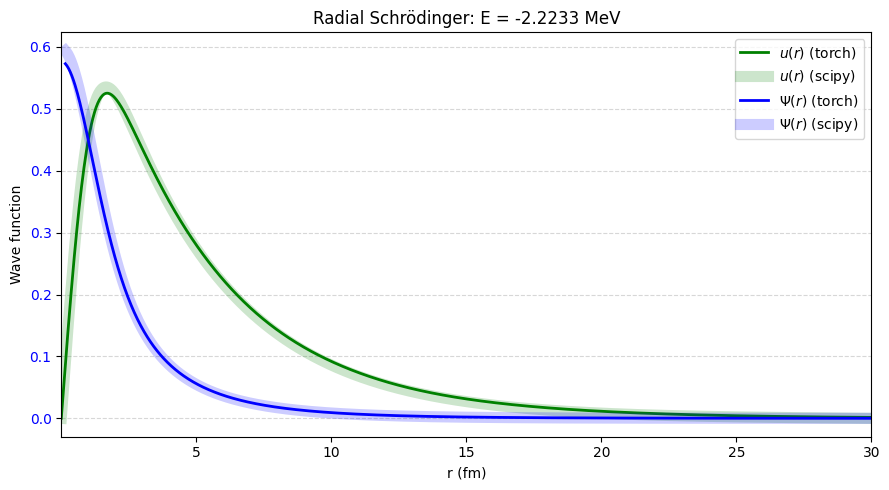

In [20]:
plot_wavefunctions(r, u_scipy, R_scipy, u_nn2, R_nn2, metrics2['learned_energy'])